In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm', 'pyarrow', 'polars', 'optuna'])

import os, gc
import pickle
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import lightgbm as lgb
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import optuna
from optuna.samplers import TPESampler

INPUT_DIR = '/kaggle/input/datasets/b22dckh072/file05/' 
TRAIN_PATH = os.path.join(INPUT_DIR, 'train_interactions.parquet')
META_PATH  = os.path.join(INPUT_DIR, 'filtered_metadata.parquet')
CAND_PATH  = os.path.join(INPUT_DIR, 'candidates_phase2.parquet')
FEAT_OUT   = os.path.join(INPUT_DIR, 'features.parquet')
TEST_PATH  = os.path.join(INPUT_DIR, 'test_interactions.parquet')

FEATURES = [
    'user_total_actions', 
    'item_total_sales', 
    'price', 
    'average_rating',
    'rating_number',
    'user_avg_rating_given',
    'item_actual_avg_rating',  
    'item_verified_ratio',      # Tỷ lệ mua thật
    'item_log_helpful_votes',   # Điểm hữu ích (Log)
    'store_popularity',         # Tên thương hiệu (Categorical)
    'main_category',            # Loại trang phục (Categorical)
    'sasrec_score', 
    'lightgcn_score'
]

Đang nạp file đặc trưng bằng Polars...
Đang chuyển qua Pandas và khóa từ điển Categorical...
Đang sắp xếp dữ liệu theo User ID (Yêu cầu bắt buộc của LightGBM Ranker)...


[I 2026-06-05 14:29:35,912] A new study created in memory with name: no-name-c5b3b5ba-a8e0-4afd-84c8-0927ad919601


Đã lưu từ điển tại /kaggle/working/category_dict.pkl
Đang chuyển đổi cấu trúc dữ liệu cho LightGBM...
Bắt đầu chiến dịch dò tìm siêu tham số với Optuna (30 Trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[I 2026-06-05 14:39:25,700] Trial 0 finished with value: 0.21026520156327042 and parameters: {'max_depth': 5, 'num_leaves': 84, 'learning_rate': 0.01239470751174391, 'subsample': 0.8481179239930698, 'colsample_bytree': 0.49814171674334196, 'min_child_samples': 89}. Best is trial 0 with value: 0.21026520156327042.
[I 2026-06-05 14:50:22,269] Trial 1 finished with value: 0.21139259257657217 and parameters: {'max_depth': 8, 'num_leaves': 77, 'learning_rate': 0.010478033749915435, 'subsample': 0.9467496592560566, 'colsample_bytree': 0.5184850055293018, 'min_child_samples': 84}. Best is trial 1 with value: 0.21139259257657217.
[I 2026-06-05 14:58:05,655] Trial 2 finished with value: 0.21070800957364103 and parameters: {'max_depth': 6, 'num_leaves': 22, 'learning_rate': 0.0403423696367838, 'subsample': 0.8442057991768743, 'colsample_bytree': 0.5214968344141779, 'min_child_samples': 45}. Best is trial 1 with value: 0.21139259257657217.
[I 2026-06-05 15:07:12,376] Trial 3 finished with value: 

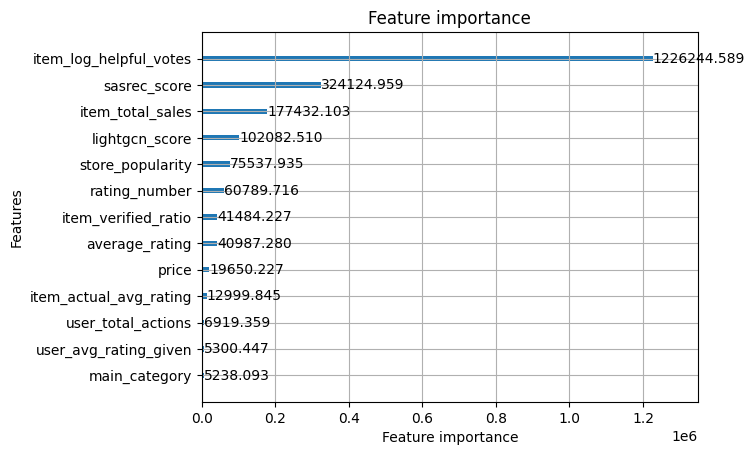

/tmp/ipykernel_23/2342962653.py:135: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


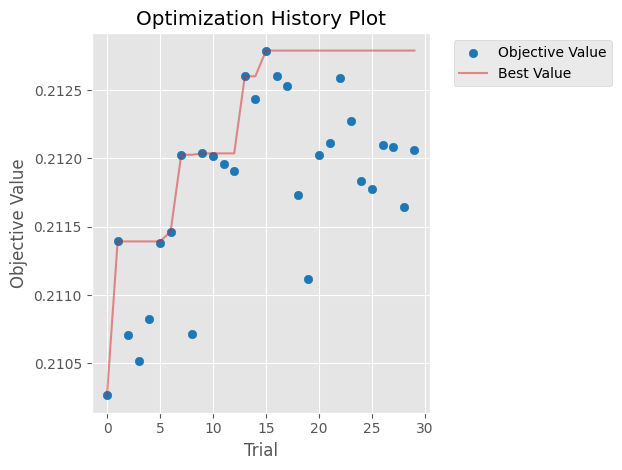

8759

In [2]:
import numpy as np
import pickle
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import gc
import polars as pl

print("Đang nạp file đặc trưng bằng Polars...")
df_train = pl.read_parquet(FEAT_OUT) 
X_train = df_train.select(FEATURES + ['mapped_user_id'])
y_train = df_train.select(['label'])

print("Đang chuyển qua Pandas và khóa từ điển Categorical...")
X_train_pd = X_train.to_pandas()
y_train_pd = y_train.to_pandas()

print("Đang sắp xếp dữ liệu theo User ID (Yêu cầu bắt buộc của LightGBM Ranker)...")
X_train_pd['label'] = y_train_pd['label']
X_train_pd = X_train_pd.sort_values('mapped_user_id').reset_index(drop=True)
y_train_pd = X_train_pd[['label']]
qid_train = X_train_pd['mapped_user_id']

# Tính toán mảng group cho LightGBM (số lượng items của mỗi user)
group_train = X_train_pd.groupby('mapped_user_id', sort=False).size().values

# ĐÃ XÓA: Khối xử lý Logarit vì dữ liệu hiện tại đã là Thứ hạng (Local Rank 1 -> 300)

# Xóa các cột không phải đặc trưng
X_train_pd = X_train_pd.drop(columns=['mapped_user_id', 'label'])
X_train_pd['main_category'] = X_train_pd['main_category'].astype(str).astype('category')

with open('/kaggle/working/category_dict.pkl', 'wb') as f:
    pickle.dump({
        'main_category': X_train_pd['main_category'].cat.categories
    }, f)
print("Đã lưu từ điển tại /kaggle/working/category_dict.pkl")

print("Đang chuyển đổi cấu trúc dữ liệu cho LightGBM...")
# LightGBM tự động nhận diện các cột có dtype là 'category'
dtrain = lgb.Dataset(X_train_pd, label=y_train_pd, group=group_train, free_raw_data=False)
del X_train_pd, y_train_pd, df_train, X_train, y_train, qid_train
gc.collect()

# LightGBM yêu cầu monotone_constraints là một list các số 1, -1, 0
constraints = {
    'sasrec_score': 1,    
    'lightgcn_score': 1   
}
mc_list = [constraints.get(f, 0) for f in FEATURES]

def objective(trial):
    param = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [10, 100], 
        'boosting_type': 'gbdt',
        'device_type': 'gpu', 
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        
        # Hạ tốc độ học xuống thấp để mô hình chú ý đến các đặc trưng tinh tế hơn
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        
        # Ép mô hình chỉ được dùng 40%-70% features mỗi lần chia nhánh
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.7),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100), 
        
        'monotone_constraints': mc_list,
        'monotone_constraints_method': 'advanced', 
        'verbose': -1,

        'feature_pre_filter': False
    }

    try:
        cv_results = lgb.cv(
            param,
            dtrain,
            num_boost_round=1500, 
            nfold=3,             
            stratified=False, 
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
            seed=42,
            return_cvbooster=False
        )
        
        best_ndcg = max(cv_results['valid ndcg@10-mean'])
        best_num_trees = len(cv_results['valid ndcg@10-mean'])
        
        trial.set_user_attr("best_num_trees", best_num_trees)
        
        return best_ndcg
        
    except lgb.basic.LightGBMError:
        raise optuna.TrialPruned()

print("Bắt đầu chiến dịch dò tìm siêu tham số với Optuna (30 Trials)...")
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=43))
study.optimize(objective, n_trials=30, show_progress_bar=True) 

print("=========================================")
print(f"Điểm NDCG tốt nhất tìm được: {study.best_value:.4f}")
print("Cấu hình siêu tham số tốt nhất:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")
print("=========================================")

print("\nTiến hành huấn luyện mô hình...")
best_params = study.best_params
best_params['objective'] = 'lambdarank'
best_params['metric'] = 'ndcg'
best_params['ndcg_eval_at'] = [10]
best_params['boosting_type'] = 'gbdt'
best_params['device_type'] = 'gpu'
best_params['monotone_constraints'] = mc_list
best_params['verbose'] = -1
best_trees = study.best_trial.user_attrs["best_num_trees"]

model = lgb.train(best_params, dtrain, num_boost_round=best_trees)

# Lưu mô hình
model_path = '/kaggle/working/lightgbm_ranking_model.txt'
model.save_model(model_path)
print(f"Huấn luyện hoàn tất! Đã lưu mô hình tinh anh tại: {model_path}")

# Trực quan hóa độ quan trọng của đặc trưng
lgb.plot_importance(model, importance_type='gain', max_num_features=15)
plt.show()

# Trực quan hóa quá trình tìm kiếm của Optuna
try:
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.show()
except:
    pass

del dtrain
gc.collect()

In [3]:
# import polars as pl

# # Trỏ đến file features.parquet
# FEAT_OUT = '/kaggle/input/datasets/b22dckh072/file05/features.parquet' 

# print("Đang quét X-quang tập dữ liệu Huấn luyện (Train Data)...")
# df_train = pl.read_parquet(FEAT_OUT)

# # Thống kê điểm trung bình của SASRec và LightGCN chia theo Nhãn (Mua thật vs Không mua)
# stats = df_train.group_by('label').agg([
#     pl.len().alias('Tổng số dòng'),
#     pl.col('sasrec_score').mean().alias('Điểm SASRec (TB)'),
#     pl.col('lightgcn_score').mean().alias('Điểm LightGCN (TB)'),
#     (pl.col('sasrec_score') == 0).sum().alias('Số món bị 0 điểm SASRec'),
# ]).sort('label', descending=True)

# print(stats)

In [4]:
# import polars as pl

# # Đọc file dữ liệu đã tạo
# df_train = pl.read_parquet(FEAT_OUT)

# # Chỉ lọc ra những món khách hàng thực sự mua (Nhãn 1)
# positives = df_train.filter(pl.col('label') == 1)

# print("Tổng số món khách mua thật (Nhãn 1):", positives.height)
# print("Số món do SASRec đoán trúng (Score > 0):", positives.filter(pl.col('sasrec_score') > 0.0).height)
# print("Số món do LightGCN đoán trúng (Score > 0):", positives.filter(pl.col('lightgcn_score') > 0.0).height)

In [5]:
import os, gc, ctypes
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import lightgbm as lgb
import polars as pl
import duckdb
from tqdm.auto import tqdm
import pickle

try:
    libc = ctypes.CDLL("libc.so.6")
    def trim_memory():
        libc.malloc_trim(0)
except:
    def trim_memory():
        pass

PROCESSED_DATA_DIR = '/kaggle/input/datasets/b22dckh072/file05' 
META_PATH  = f'{PROCESSED_DATA_DIR}/filtered_metadata.parquet'
TRAIN_PATH = f'{PROCESSED_DATA_DIR}/train_interactions.parquet'
CAND_PATH  = f'{PROCESSED_DATA_DIR}/candidates_phase2.parquet'
TEST_PATH  = f'{PROCESSED_DATA_DIR}/test_interactions.parquet'

MODEL_PATH = '/kaggle/working/lightgbm_ranking_model.txt' 
DICT_PATH  = '/kaggle/working/category_dict.pkl'

FEATURES = [
    'user_total_actions', 
    'item_total_sales', 
    'price', 
    'average_rating',
    'rating_number',
    'user_avg_rating_given',
    'item_actual_avg_rating',
    'item_verified_ratio',      
    'item_log_helpful_votes',   
    'store_popularity',                    
    'main_category',       
    'sasrec_score',
    'lightgcn_score' 
]

print("=========================================")
print("PHAN 1: DU DOAN VA LOC TOP 100")
print("=========================================")
print("Dang nap mo hinh LightGBM va bo tu dien...")
model = lgb.Booster(model_file=MODEL_PATH)

with open(DICT_PATH, 'rb') as f:
    cat_dict = pickle.load(f)
valid_categories = cat_dict['main_category']

print("Dang chuan bi dac trung Item va User...")
lf_train = pl.scan_parquet(TRAIN_PATH)
lf_meta = pl.scan_parquet(META_PATH)

df_use = (
    lf_train.group_by('mapped_user_id').agg([
        pl.len().alias('user_total_actions').cast(pl.Float32),
        pl.col('rating').mean().alias('user_avg_rating_given').cast(pl.Float32)
    ]).collect()
)

df_ite = (
    lf_train.group_by('mapped_item_id').agg([
        pl.len().alias('item_total_sales').cast(pl.Float32),
        pl.col('rating').mean().alias('item_actual_avg_rating').cast(pl.Float32),
        pl.col('verified_purchase').cast(pl.Float32).sum().alias('item_verified_sales'),
        pl.col('helpful_vote').cast(pl.Float32).sum().alias('item_raw_helpful_votes')
    ]).with_columns([
        (pl.col('item_verified_sales') / pl.col('item_total_sales')).fill_null(0.0).alias('item_verified_ratio'),
        (pl.col('item_raw_helpful_votes') + 1.0).log().alias('item_log_helpful_votes')
    ]).drop(['item_verified_sales', 'item_raw_helpful_votes']).collect()
)
store_counts = lf_meta.group_by('store').agg(pl.len().cast(pl.Float32).alias('store_popularity')).collect()

df_meta_feats = (
    lf_meta.select(['mapped_item_id', 'price', 'average_rating', 'rating_number', 'store', 'categories'])
    .with_columns([
        pl.col('price').cast(pl.Utf8).str.replace_all(r'[^0-9.]', '').cast(pl.Float32, strict=False),
        pl.col('categories').cast(pl.Utf8)
          .str.replace_all(r"\[|\]|'|\"", "")
          .str.split(',')
          .list.get(2)
          .str.strip_chars()
          .fill_null('Unknown')
          .cast(pl.Categorical)
          .alias('main_category')
    ])
    .collect()
    .join(store_counts, on='store', how='left') 
    .drop(['store', 'categories'])              
    .unique(subset=['mapped_item_id'])
)

del lf_train, lf_meta, store_counts
gc.collect()
trim_memory()

print("Bat dau qua trinh cham diem hang loat (Co su dung Buffer de tinh Rank)...")
pf = pq.ParquetFile(CAND_PATH)
reader = pf.iter_batches(batch_size=1500000) # Tăng lên 1.5 triệu để quét nhanh hơn
writer = None
TMP_SCORE_PATH = '/kaggle/working/tmp_scores.parquet'

buffer_df = pl.DataFrame()

for batch in tqdm(reader, desc="Scoring Chunks"):
    chunk = pl.from_arrow(batch)
    
    # Nối lại phần dư từ chunk trước
    if buffer_df.height > 0:
        chunk = pl.concat([buffer_df, chunk])
        
    last_user = chunk.get_column('mapped_user_id')[-1]
    
    # Tách riêng User cuối cùng để làm buffer cho lượt sau (Tránh cắt đôi 300 món)
    completed = chunk.filter(pl.col('mapped_user_id') != last_user)
    buffer_df = chunk.filter(pl.col('mapped_user_id') == last_user)
    
    if completed.height > 0:
        # 1. Nối đặc trưng
        completed = completed.join(df_use, on='mapped_user_id', how='left')
        completed = completed.join(df_ite, on='mapped_item_id', how='left')
        completed = completed.join(df_meta_feats, on='mapped_item_id', how='left')
        
        # 2. Xử lý giá trị rỗng và làm sạch
        completed = completed.with_columns([
            ((201.0 - pl.col('sasrec_rank').cast(pl.Float32)).clip(lower_bound=0.0)).fill_null(0.0).alias('sasrec_score'),
            ((201.0 - pl.col('lightgcn_rank').cast(pl.Float32)).clip(lower_bound=0.0)).fill_null(0.0).alias('lightgcn_score'),
            
            pl.col('average_rating').fill_null(3.0),
            pl.col('rating_number').fill_null(0.0).cast(pl.Float32),
            pl.col('user_total_actions').fill_null(0.0),
            pl.col('item_total_sales').fill_null(0.0).cast(pl.Float32),
            pl.col('user_avg_rating_given').fill_null(3.0),
            pl.col('item_actual_avg_rating').fill_null(3.0),
            pl.col('item_verified_ratio').fill_null(0.0),
            pl.col('item_log_helpful_votes').fill_null(0.0).cast(pl.Float32),
            pl.col('store_popularity').fill_null(0.0).cast(pl.Float32),
            pl.col('main_category').fill_null('Unknown')
        ])
        
        # ==============================================================================
        # 3. [UPDATE QUAN TRỌNG]: ÉP VỀ LOCAL RANK (Khớp 100% với lúc Training File 05)
        # ==============================================================================
        completed = completed.with_columns([
            pl.col('item_total_sales').rank(descending=True).over('mapped_user_id').alias('item_total_sales'),
            pl.col('rating_number').rank(descending=True).over('mapped_user_id').alias('rating_number'),
            pl.col('item_log_helpful_votes').rank(descending=True).over('mapped_user_id').alias('item_log_helpful_votes'),
            pl.col('store_popularity').rank(descending=True).over('mapped_user_id').alias('store_popularity')
        ])
        
        # 4. Đưa vào LightGBM
        X_cands_pd = completed.select(FEATURES).to_pandas()
        X_cands_pd['main_category'] = pd.Categorical(X_cands_pd['main_category'].astype(str), categories=valid_categories)
        
        scores = model.predict(X_cands_pd)
        
        chunk_res = pl.DataFrame({
            'mapped_user_id': completed['mapped_user_id'],
            'mapped_item_id': completed['mapped_item_id'],
            'score': pl.Series(scores, dtype=pl.Float32)
        })
        
        table = chunk_res.to_arrow()
        if writer is None:
            writer = pq.ParquetWriter(TMP_SCORE_PATH, table.schema)
        writer.write_table(table)
        
        del completed, X_cands_pd, scores, chunk_res, table
        gc.collect()
        trim_memory()

# ===== XỬ LÝ PHẦN BUFFER CUỐI CÙNG =====
if buffer_df.height > 0:
    completed = buffer_df.join(df_use, on='mapped_user_id', how='left')
    completed = completed.join(df_ite, on='mapped_item_id', how='left')
    completed = completed.join(df_meta_feats, on='mapped_item_id', how='left')
    
    completed = completed.with_columns([
        ((201.0 - pl.col('sasrec_rank').cast(pl.Float32)).clip(lower_bound=0.0)).fill_null(0.0).alias('sasrec_score'),
        ((201.0 - pl.col('lightgcn_rank').cast(pl.Float32)).clip(lower_bound=0.0)).fill_null(0.0).alias('lightgcn_score'),
        pl.col('average_rating').fill_null(3.0),
        pl.col('rating_number').fill_null(0.0).cast(pl.Float32),
        pl.col('user_total_actions').fill_null(0.0),
        pl.col('item_total_sales').fill_null(0.0).cast(pl.Float32),
        pl.col('user_avg_rating_given').fill_null(3.0),
        pl.col('item_actual_avg_rating').fill_null(3.0),
        pl.col('item_verified_ratio').fill_null(0.0),
        pl.col('item_log_helpful_votes').fill_null(0.0).cast(pl.Float32),
        pl.col('store_popularity').fill_null(0.0).cast(pl.Float32),
        pl.col('main_category').fill_null('Unknown')
    ]).with_columns([
        pl.col('item_total_sales').rank(descending=True).over('mapped_user_id').alias('item_total_sales'),
        pl.col('rating_number').rank(descending=True).over('mapped_user_id').alias('rating_number'),
        pl.col('item_log_helpful_votes').rank(descending=True).over('mapped_user_id').alias('item_log_helpful_votes'),
        pl.col('store_popularity').rank(descending=True).over('mapped_user_id').alias('store_popularity')
    ])
    
    X_cands_pd = completed.select(FEATURES).to_pandas()
    X_cands_pd['main_category'] = pd.Categorical(X_cands_pd['main_category'].astype(str), categories=valid_categories)
    scores = model.predict(X_cands_pd)
    
    chunk_res = pl.DataFrame({
        'mapped_user_id': completed['mapped_user_id'],
        'mapped_item_id': completed['mapped_item_id'],
        'score': pl.Series(scores, dtype=pl.Float32)
    })
    
    table = chunk_res.to_arrow()
    if writer is None:
        writer = pq.ParquetWriter(TMP_SCORE_PATH, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

print("Dang thuc hien sap xep toan cuc de lay Top 100 bang DuckDB...")
FINAL_TOP100_PATH = '/kaggle/working/top100_final_recommendations.parquet'

duckdb.sql(f"""
    COPY (
        SELECT mapped_user_id, mapped_item_id, score
        FROM read_parquet('{TMP_SCORE_PATH}')
        QUALIFY ROW_NUMBER() OVER (PARTITION BY mapped_user_id ORDER BY score DESC, mapped_item_id ASC) <= 100
    ) TO '{FINAL_TOP100_PATH}' (FORMAT PARQUET);
""")

print("\n=========================================")
print("PHAN 2: DANH GIA MO HINH TREN TAP TEST")
print("=========================================")
print("Dang nap tap Test va khoi tao danh sach doi chieu...")
df_test = pl.read_parquet(TEST_PATH)
truth_df = df_test.group_by('mapped_user_id').agg(pl.col('mapped_item_id').alias('true_items'))
truth_df = truth_df.filter((pl.col('mapped_user_id') % 2) != 0)

truth_df = truth_df.with_columns([
    pl.col('true_items').list.len().alias('num_true')
])

def get_idcg_10(n):
    return sum(1.0 / np.log2(i + 1) for i in range(1, min(n, 10) + 1))

truth_df = truth_df.with_columns(
    pl.col('num_true').map_elements(get_idcg_10, return_dtype=pl.Float64).alias('idcg_10')
)

n_valid = truth_df.height
print(f"So luong nguoi dung hop le trong tap Test: {n_valid:,}")
print("Dang tinh toan chi so bang luong du lieu (Streaming Evaluation)...")

pf_eval = pq.ParquetFile(FINAL_TOP100_PATH)
reader_eval = pf_eval.iter_batches(batch_size=5000000, columns=['mapped_user_id', 'mapped_item_id', 'score'])

hr100_sum = 0
rc100_sum = 0.0  
hr10_sum = 0
rc10_sum = 0.0  
p10_sum = 0.0 
ndcg10_sum = 0.0

buffer_df = pl.DataFrame()

for batch in tqdm(reader_eval, desc="Evaluating Chunks"):
    chunk = pl.from_arrow(batch)
    
    if buffer_df.height > 0:
        chunk = pl.concat([buffer_df, chunk])
        
    last_user = chunk.get_column('mapped_user_id')[-1]
    
    completed = chunk.filter(pl.col('mapped_user_id') != last_user)
    buffer_df = chunk.filter(pl.col('mapped_user_id') == last_user)
    
    if completed.height > 0:
        completed = completed.with_columns(
            pl.col('score').rank(method='ordinal', descending=True).over('mapped_user_id').alias('rank')
        )
        
        top100 = completed.filter(pl.col('rank') <= 100)
        eval_df = top100.join(truth_df, on='mapped_user_id', how='inner')
        
        eval_df = eval_df.with_columns(
            pl.col('true_items').list.contains(pl.col('mapped_item_id')).alias('is_hit')
        )
        
        hits_only = eval_df.filter(pl.col('is_hit'))
        
        if hits_only.height > 0:
            user_metrics = hits_only.group_by('mapped_user_id').agg([
                pl.len().alias('hits_100'),
                (pl.col('rank') <= 10).sum().alias('hits_10'),
                
                pl.when(pl.col('rank') <= 10)
                  .then(1.0 / (pl.col('rank') + 1).log(2))
                  .otherwise(0.0)
                  .sum()
                  .alias('dcg_10'),
                  
                pl.col('num_true').first().alias('num_true'),
                pl.col('idcg_10').first().alias('idcg_10')
            ])
            
            hr100_sum += user_metrics.height 
            rc100_sum += (user_metrics['hits_100'] / user_metrics['num_true']).sum()
            
            hr10_sum += (user_metrics['hits_10'] > 0).sum()
            rc10_sum += (user_metrics['hits_10'] / user_metrics['num_true']).sum()
            p10_sum += (user_metrics['hits_10'] / 10.0).sum()
            
            ndcg10_sum += (user_metrics['dcg_10'] / user_metrics['idcg_10']).sum()
            
        del top100, eval_df, hits_only
        
    del chunk, completed
    gc.collect()

if buffer_df.height > 0:
    buffer_df = buffer_df.with_columns(
        pl.col('score').rank(method='ordinal', descending=True).over('mapped_user_id').alias('rank')
    )
    top100 = buffer_df.filter(pl.col('rank') <= 100)
    eval_df = top100.join(truth_df, on='mapped_user_id', how='inner')
    eval_df = eval_df.with_columns(
        pl.col('true_items').list.contains(pl.col('mapped_item_id')).alias('is_hit')
    )
    hits_only = eval_df.filter(pl.col('is_hit'))
    
    if hits_only.height > 0:
        user_metrics = hits_only.group_by('mapped_user_id').agg([
            pl.len().alias('hits_100'),
            (pl.col('rank') <= 10).sum().alias('hits_10'),
            pl.when(pl.col('rank') <= 10).then(1.0 / (pl.col('rank') + 1).log(2)).otherwise(0.0).sum().alias('dcg_10'),
            pl.col('num_true').first().alias('num_true'),
            pl.col('idcg_10').first().alias('idcg_10')
        ])
        
        hr100_sum += user_metrics.height 
        rc100_sum += (user_metrics['hits_100'] / user_metrics['num_true']).sum()
        
        hr10_sum += (user_metrics['hits_10'] > 0).sum()
        rc10_sum += (user_metrics['hits_10'] / user_metrics['num_true']).sum()
        p10_sum += (user_metrics['hits_10'] / 10.0).sum()
        
        ndcg10_sum += (user_metrics['dcg_10'] / user_metrics['idcg_10']).sum()

HR100 = hr100_sum / n_valid
RC100 = rc100_sum / n_valid
HR10 = hr10_sum / n_valid
RC10 = rc10_sum / n_valid
P10 = p10_sum / n_valid  
NDCG10 = ndcg10_sum / n_valid

print("=======================================")
print(f"KET QUA DANH GIA MO HINH LIGHTGBM CHUAN")
print(f"Tap nguoi dung hop le (Le): {n_valid:,}")
print(f"Hit Rate @ 100  (HR@100):   {HR100:.4f}")
print(f"Recall @ 100    (RC@100):   {RC100:.4f}")
print("---------------------------------------")
print(f"Hit Rate @ 10   (HR@10):    {HR10:.4f}")
print(f"Recall @ 10     (RC@10):    {RC10:.4f}")
print(f"Precision @ 10  (P@10):     {P10:.4f}")
print(f"NDCG @ 10:                  {NDCG10:.4f}")
print("=======================================")

PHAN 1: DU DOAN VA LOC TOP 100
Dang nap mo hinh LightGBM va bo tu dien...
Dang chuan bi dac trung Item va User...
Bat dau qua trinh cham diem hang loat (Co su dung Buffer de tinh Rank)...


Scoring Chunks: 0it [00:00, ?it/s]

Dang thuc hien sap xep toan cuc de lay Top 100 bang DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


PHAN 2: DANH GIA MO HINH TREN TAP TEST
Dang nap tap Test va khoi tao danh sach doi chieu...
So luong nguoi dung hop le trong tap Test: 516,025
Dang tinh toan chi so bang luong du lieu (Streaming Evaluation)...


Evaluating Chunks: 0it [00:00, ?it/s]

KET QUA DANH GIA MO HINH LIGHTGBM CHUAN
Tap nguoi dung hop le (Le): 516,025
Hit Rate @ 100  (HR@100):   0.1131
Recall @ 100    (RC@100):   0.0497
---------------------------------------
Hit Rate @ 10   (HR@10):    0.0470
Recall @ 10     (RC@10):    0.0199
Precision @ 10  (P@10):     0.0049
NDCG @ 10:                  0.0191
